# Лабораторная работа №4
## Сравнительный анализ алгоритмов классификации

**Выполнил:** _Машканов Михаил Вячеславович_
**Группа:** _14_

**Среда выполнения:** Anaconda Jupyter Notebook, окружение conda `lab1_terminal`.

**Цель работы:** практическое освоение методов машинного обучения для решения задач
классификации, изучение метрик оценки качества классификаторов, исследование влияния
гиперпараметров на точность моделей, а также применение интерактивной визуализации.

---
# Часть 1. Наборы данных и постановка задачи

Выбраны два новых набора данных, не использованных в ЛР №1–3:

| № | Набор данных | Файл | Задача |
|---|---|---|---|
| 1 | [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (UCI) — диагностика опухолей | `data/breast_cancer.csv` | бинарная классификация `diagnosis`: M / B |
| 2 | [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM, Kaggle) — отток клиентов | `data/Telco-Customer-Churn.csv` | бинарная классификация `Churn`: Yes / No |

Классификаторы: k-ближайших соседей (kNN), дерево решений, метод опорных векторов (SVM)
и многослойный персептрон (MLP). Для каждого гиперпараметры подбираются `GridSearchCV`
с 5-кратной стратифицированной кросс-валидацией. Предобработка (кодирование, масштабирование,
заполнение пропусков) встроена в `Pipeline`, поэтому на каждом шаге кросс-валидации она
обучается только на обучающих фолдах — без утечки данных из валидационной части.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
TEST_SIZE, SEED = 0.2, 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Классификаторы и сетки гиперпараметров (префикс clf__ — шаг модели в Pipeline)
MODELS = {
    "kNN": (KNeighborsClassifier(), {
        "clf__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
    }),
    "Decision Tree": (DecisionTreeClassifier(random_state=SEED), {
        "clf__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
        "clf__min_samples_leaf": [1, 5, 10, 20],
        "clf__criterion": ["gini", "entropy"],
    }),
    "SVM": (SVC(random_state=SEED), {
        "clf__kernel": ["linear", "rbf", "poly"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.01],
    }),
    "MLP": (MLPClassifier(max_iter=2000, random_state=SEED), {
        "clf__hidden_layer_sizes": [(32,), (64,), (64, 32)],
        "clf__activation": ["relu", "tanh"],
        "clf__alpha": [1e-4, 1e-2, 1],
    }),
}


def tune_models(preprocess, X_train, y_train):
    # GridSearchCV для каждого классификатора; возвращает лучшие обученные пайплайны
    best, rows = {}, []
    for name, (clf, grid) in MODELS.items():
        search = GridSearchCV(Pipeline([("prep", preprocess), ("clf", clf)]), grid,
                              scoring="f1_macro", cv=CV, n_jobs=-1)
        search.fit(X_train, y_train)
        best[name] = search.best_estimator_
        params = {k.removeprefix("clf__"): v for k, v in search.best_params_.items()}
        rows.append({"Модель": name, "F1-macro (CV)": search.best_score_, "Лучшие параметры": params})
    display(pd.DataFrame(rows).set_index("Модель").style.format({"F1-macro (CV)": "{:.4f}"}))
    return best


def evaluate_models(models, X_test, y_test, labels):
    # Матрицы неточностей, classification report и сводная таблица метрик на тесте
    fig, axes = plt.subplots(1, len(models), figsize=(4.5 * len(models), 4))
    rows = []
    for ax, (name, model) in zip(axes, models.items()):
        pred = model.predict(X_test)
        ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=labels,
                                                cmap="Blues", colorbar=False, ax=ax)
        ax.set_title(name)
        print(f"=== {name} ===")
        print(classification_report(y_test, pred, target_names=labels, digits=4))
        rows.append({"Модель": name,
                     "Accuracy": accuracy_score(y_test, pred),
                     "Precision": precision_score(y_test, pred, average="macro"),
                     "Recall": recall_score(y_test, pred, average="macro"),
                     "F1-score": f1_score(y_test, pred, average="macro")})
    fig.suptitle("Матрицы неточностей на тестовой выборке")
    fig.tight_layout()
    plt.show()
    return pd.DataFrame(rows).set_index("Модель")

---
# Набор 1. Breast Cancer Wisconsin

## Постановка задачи

* **Бизнес-задача:** по результатам анализа биопсии помочь врачу отличить злокачественную
  опухоль от доброкачественной; ошибка «пропустить злокачественную» (ложноотрицательный
  результат для класса M) наиболее опасна.
* **Объект:** клеточный образец, полученный тонкоигольной аспирационной биопсией молочной железы.
* **Признаки:** 30 числовых характеристик ядер клеток на оцифрованном снимке — для 10 величин
  (радиус, текстура, периметр, площадь, гладкость, компактность, вогнутость, число вогнутых
  точек, симметрия, фрактальная размерность) взяты среднее (`mean`), стандартная ошибка (`error`)
  и наихудшее значение (`worst`).
* **Целевая переменная:** `diagnosis` — M (malignant, злокачественная) или B (benign, доброкачественная).
* **Математическая задача:** бинарная классификация — построить отображение
  $a: \mathbb{R}^{30} \to \{B, M\}$, максимизирующее качество на новых объектах.

In [2]:
cancer = pd.read_csv(DATA_DIR / "breast_cancer.csv")
display(cancer.head())
print("Размерность:", cancer.shape)
print("Пропуски:", cancer.isna().sum().sum(), "| дубликаты:", cancer.duplicated().sum())
print("Типы признаков:", cancer.dtypes.value_counts().to_dict())
print("Баланс классов:", cancer["diagnosis"].value_counts().to_dict())

,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Размерность: (569, 31)
Пропуски: 0 | дубликаты: 0
Типы признаков: {dtype('float64'): 30, <StringDtype(na_value=nan)>: 1}
Баланс классов: {'B': 357, 'M': 212}


## Предобработка и разделение выборки

Пропусков и категориальных признаков нет. Признаки имеют сильно разные масштабы
(например, `mean area` ~ сотни, `mean smoothness` ~ 0.1), что критично для kNN, SVM и MLP,
поэтому все признаки масштабируются `StandardScaler`. Целевая переменная кодируется: M → 1, B → 0.
Разбиение 80/20 с сохранением пропорций классов (`stratify`).

In [3]:
X_c = cancer.drop(columns="diagnosis")
y_c = (cancer["diagnosis"] == "M").astype(int)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_c, y_c, test_size=TEST_SIZE, stratify=y_c, random_state=SEED)

print("train:", Xc_train.shape, "доля M =", round(yc_train.mean(), 3))
print("test: ", Xc_test.shape, "доля M =", round(yc_test.mean(), 3))

prep_c = StandardScaler()

train: (455, 30) доля M = 0.374
test:  (114, 30) доля M = 0.368


## Подбор гиперпараметров (GridSearchCV, 5-fold CV, метрика F1-macro)

In [4]:
cancer_models = tune_models(prep_c, Xc_train, yc_train)

,F1-macro (CV),Лучшие параметры
Модель,,
kNN,0.9739,"{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}"
Decision Tree,0.9332,"{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1}"
SVM,0.9741,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"
MLP,0.9765,"{'activation': 'relu', 'alpha': 1, 'hidden_layer_sizes': (64,)}"


## Оценка на тестовой выборке

=== kNN ===
              precision    recall  f1-score   support

           B     0.9474    1.0000    0.9730        72
           M     1.0000    0.9048    0.9500        42

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted avg     0.9668    0.9649    0.9645       114

=== Decision Tree ===
              precision    recall  f1-score   support

           B     0.9000    1.0000    0.9474        72
           M     1.0000    0.8095    0.8947        42

    accuracy                         0.9298       114
   macro avg     0.9500    0.9048    0.9211       114
weighted avg     0.9368    0.9298    0.9280       114

=== SVM ===
              precision    recall  f1-score   support

           B     0.9600    1.0000    0.9796        72
           M     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0

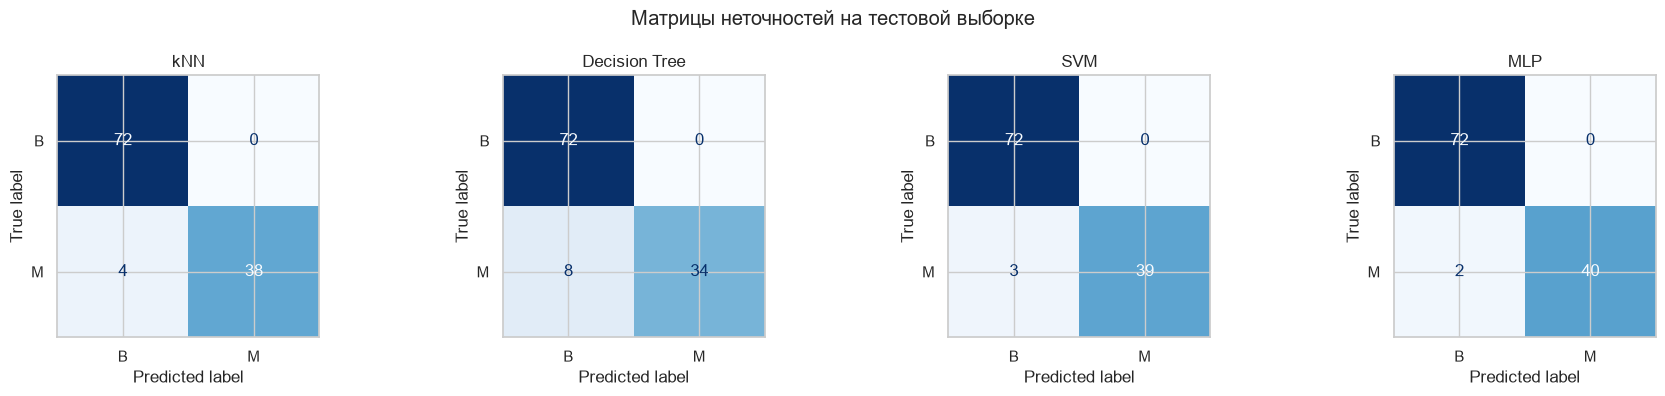

,Accuracy,Precision,Recall,F1-score
Модель,,,,
kNN,0.9649,0.9737,0.9524,0.9615
Decision Tree,0.9298,0.9500,0.9048,0.9211
SVM,0.9737,0.9800,0.9643,0.9713
MLP,0.9825,0.9865,0.9762,0.9810


In [5]:
cancer_metrics = evaluate_models(cancer_models, Xc_test, yc_test, labels=["B", "M"])
cancer_metrics.style.format(precision=4).highlight_max(color="lightgreen")

---
# Набор 2. Telco Customer Churn

## Постановка задачи

* **Бизнес-задача:** заранее выявить клиентов телеком-оператора, склонных уйти, чтобы
  предложить им удерживающие акции; важно находить как можно больше уходящих клиентов
  (полнота класса Yes).
* **Объект:** клиент оператора связи.
* **Признаки (19):** демография (`gender`, `SeniorCitizen`, `Partner`, `Dependents`),
  подключённые услуги (`PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`,
  `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`),
  договор и оплата (`tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`,
  `MonthlyCharges`, `TotalCharges`). `customerID` — идентификатор, в модели не используется.
* **Целевая переменная:** `Churn` — ушёл ли клиент в последний месяц (Yes / No).
* **Математическая задача:** бинарная классификация с несбалансированными классами
  по смешанному (числовому и категориальному) описанию объекта.

In [6]:
telco = pd.read_csv(DATA_DIR / "Telco-Customer-Churn.csv")
display(telco.head())
print("Размерность:", telco.shape)
print("Дубликаты:", telco.duplicated().sum())
print("Типы признаков:", telco.dtypes.value_counts().to_dict())
print("Баланс классов:", telco["Churn"].value_counts().to_dict())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Размерность: (7043, 21)
Дубликаты: 0
Типы признаков: {<StringDtype(na_value=nan)>: 18, dtype('int64'): 2, dtype('float64'): 1}
Баланс классов: {'No': 5174, 'Yes': 1869}


## Предобработка и разделение выборки

`TotalCharges` прочитан как строка: у новых клиентов (`tenure = 0`) вместо суммы стоит пробел.
Преобразуем столбец в число — пробелы становятся пропусками `NaN`.

In [7]:
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce")
print("Пропуски после преобразования:", telco.isna().sum()[lambda s: s > 0].to_dict())
display(telco.loc[telco["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "TotalCharges"]])

Пропуски после преобразования: {'TotalCharges': 11}


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Пропуски заполняются медианой (`SimpleImputer`), числовые признаки масштабируются
`StandardScaler`, категориальные кодируются `OneHotEncoder` (с удалением одной из двух
категорий у бинарных признаков). Все шаги собраны в `ColumnTransformer` внутри пайплайна.
Целевая переменная: Yes → 1, No → 0. Разбиение 80/20 со `stratify`.

In [8]:
X_t = telco.drop(columns=["customerID", "Churn"])
y_t = (telco["Churn"] == "Yes").astype(int)
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X_t.columns if c not in num_cols]   # SeniorCitizen (0/1) тоже категориальный

prep_t = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat_cols),
])

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_t, y_t, test_size=TEST_SIZE, stratify=y_t, random_state=SEED)
print("train:", Xt_train.shape, "доля Yes =", round(yt_train.mean(), 3))
print("test: ", Xt_test.shape, "доля Yes =", round(yt_test.mean(), 3))
print("Признаков после кодирования:", prep_t.fit(Xt_train).transform(Xt_train).shape[1])

train: (5634, 19) доля Yes = 0.265
test:  (1409, 19) доля Yes = 0.265
Признаков после кодирования: 40


## Подбор гиперпараметров (GridSearchCV, 5-fold CV, метрика F1-macro)

In [9]:
telco_models = tune_models(prep_t, Xt_train, yt_train)

,F1-macro (CV),Лучшие параметры
Модель,,
kNN,0.7318,"{'n_neighbors': 21, 'p': 2, 'weights': 'uniform'}"
Decision Tree,0.7179,"{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20}"
SVM,0.7260,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}"
MLP,0.7350,"{'activation': 'relu', 'alpha': 1, 'hidden_layer_sizes': (64, 32)}"


## Оценка на тестовой выборке

=== kNN ===
              precision    recall  f1-score   support

          No     0.8456    0.8570    0.8512      1035
         Yes     0.5889    0.5668    0.5777       374

    accuracy                         0.7800      1409
   macro avg     0.7172    0.7119    0.7145      1409
weighted avg     0.7774    0.7800    0.7786      1409

=== Decision Tree ===
              precision    recall  f1-score   support

          No     0.8493    0.8821    0.8654      1035
         Yes     0.6347    0.5668    0.5989       374

    accuracy                         0.7984      1409
   macro avg     0.7420    0.7245    0.7321      1409
weighted avg     0.7923    0.7984    0.7947      1409



=== SVM ===
              precision    recall  f1-score   support

          No     0.8382    0.8812    0.8592      1035
         Yes     0.6168    0.5294    0.5698       374

    accuracy                         0.7878      1409
   macro avg     0.7275    0.7053    0.7145      1409
weighted avg     0.7795    0.7878    0.7824      1409

=== MLP ===
              precision    recall  f1-score   support

          No     0.8353    0.9111    0.8715      1035
         Yes     0.6714    0.5027    0.5749       374

    accuracy                         0.8027      1409
   macro avg     0.7533    0.7069    0.7232      1409
weighted avg     0.7918    0.8027    0.7928      1409



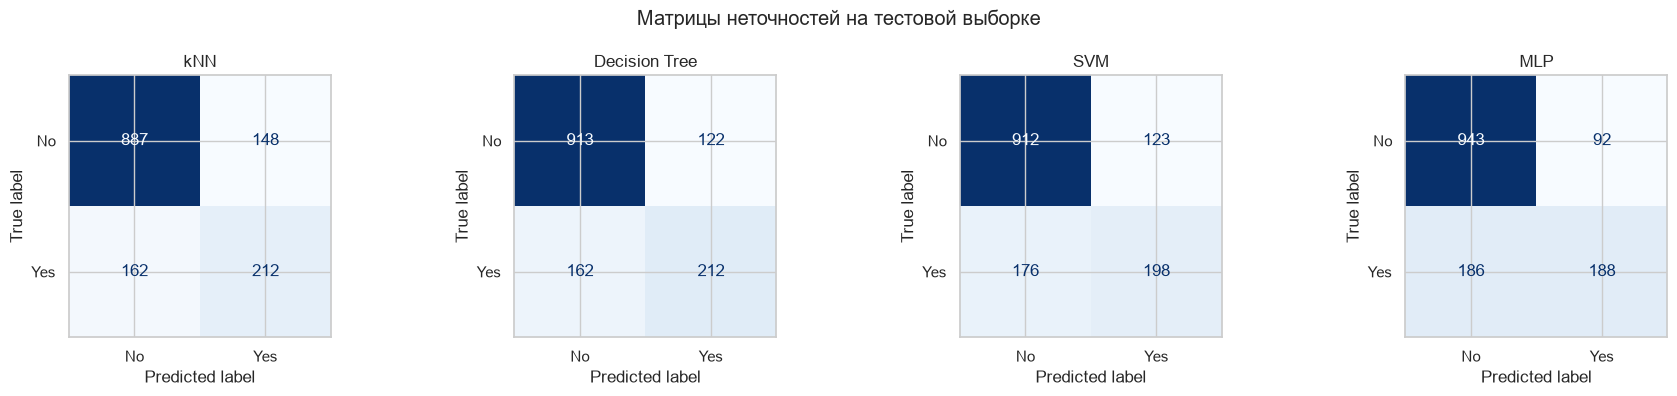

,Accuracy,Precision,Recall,F1-score
Модель,,,,
kNN,0.7800,0.7172,0.7119,0.7145
Decision Tree,0.7984,0.7420,0.7245,0.7321
SVM,0.7878,0.7275,0.7053,0.7145
MLP,0.8027,0.7533,0.7069,0.7232


In [10]:
telco_metrics = evaluate_models(telco_models, Xt_test, yt_test, labels=["No", "Yes"])
telco_metrics.style.format(precision=4).highlight_max(color="lightgreen")

---
# Часть 3. Сравнительный анализ

Precision, Recall и F1-score в сводных таблицах усреднены по классам (macro);
значения по каждому классу приведены в classification report выше.

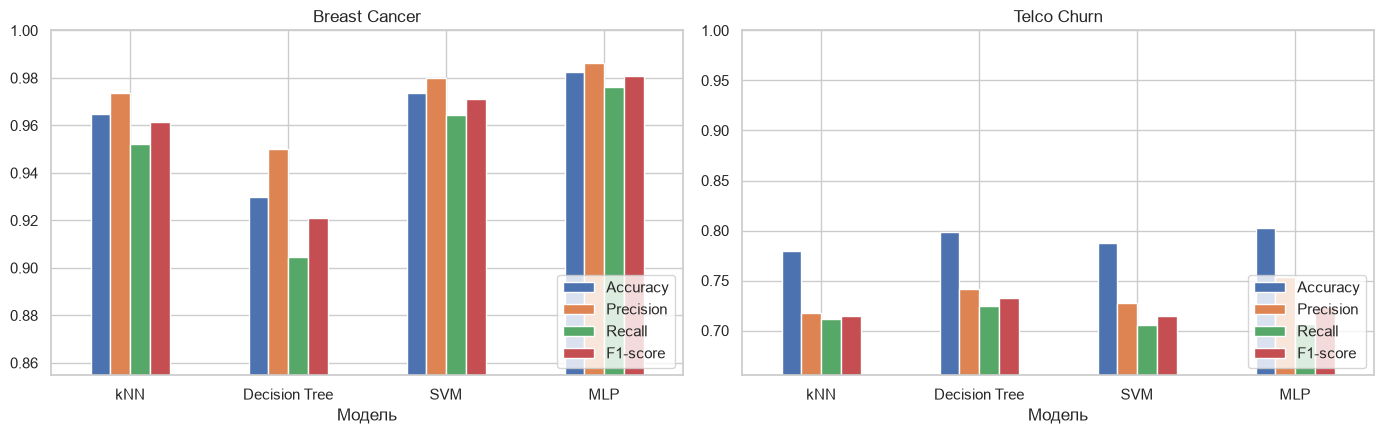

In [11]:
comparison = pd.concat({"Breast Cancer": cancer_metrics, "Telco Churn": telco_metrics}, axis=1)
display(comparison.style.format(precision=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (title, m) in zip(axes, [("Breast Cancer", cancer_metrics), ("Telco Churn", telco_metrics)]):
    m.plot.bar(ax=ax, rot=0, ylim=(m.values.min() - 0.05, 1))
    ax.set_title(title)
    ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

Лучшие модели и данные для Streamlit-приложения (дополнительное задание) сохраняются в файл:

In [12]:
joblib.dump({
    "Breast Cancer": {"models": cancer_models, "split": (Xc_train, Xc_test, yc_train, yc_test), "labels": ["B", "M"]},
    "Telco Churn": {"models": telco_models, "split": (Xt_train, Xt_test, yt_train, yt_test), "labels": ["No", "Yes"]},
}, "models.joblib")
print("Сохранено: models.joblib")

Сохранено: models.joblib


## Выводы

* **Breast Cancer.** Классы хорошо разделимы: все модели дают accuracy ≥ 0.93. Лучший
  результат у MLP (accuracy 0.982, F1-macro 0.981) и SVM с RBF-ядром (0.974 / 0.971),
  затем kNN (0.965 / 0.962). Дерево решений слабее (0.930 / 0.921): оно строит разбиения
  по отдельным признакам и хуже моделирует гладкую границу классов. Все модели не дают
  ложных срабатываний для класса M (precision = 1.0), а основные ошибки — пропуски
  злокачественных опухолей; меньше всего их у MLP (recall M = 0.95, 2 из 42).
* **Telco Churn.** Задача заметно сложнее: при дисбалансе 73.5 % / 26.5 % accuracy
  0.78–0.80 лишь немного выше константного прогноза «No» (0.735), поэтому сравнивать модели
  нужно по F1-macro и полноте класса Yes. Модели близки по качеству (F1-macro 0.71–0.73);
  лучший F1-macro у дерева решений (0.732), лучшая accuracy и precision — у MLP (0.803 / 0.753).
  Полнота класса Yes у всех моделей лишь 0.50–0.57: примерно половина уходящих клиентов
  не выявляется. Для бизнес-задачи это можно улучшить взвешиванием классов
  (`class_weight="balanced"`) или сдвигом порога классификации.
* **Гиперпараметры.** На Telco оптимальны более «простые», сильнее регуляризованные модели:
  kNN с 21 соседом (против 3 на Breast Cancer), неглубокое дерево (`max_depth=5`,
  `min_samples_leaf=20`), линейный SVM с `C=0.1`, MLP с `alpha=1` — на зашумлённых данных
  сложные модели переобучаются. Результаты кросс-валидации и теста согласованы, что
  подтверждает отсутствие переобучения при подборе параметров.

---
# Часть 4. Дополнительное задание — Streamlit

Веб-приложение [`app_streamlit.py`](app_streamlit.py) загружает `models.joblib`. В боковой
панели выбирается набор данных и классификатор (`st.selectbox`), а элементы управления
(ползунки, списки) позволяют менять его основные гиперпараметры; начальные значения — найденные
`GridSearchCV`. При каждом изменении модель переобучается на обучающей выборке, и в реальном
времени обновляются матрица неточностей, таблица метрик и classification report на тесте.

Запуск (после выполнения блокнота):

```bat
conda activate lab1_terminal
streamlit run app_streamlit.py
```